In [91]:
# STATS
import pandas as pd
from pathlib import Path
import numpy as np
from scipy.io import wavfile
import os
import matplotlib.pyplot as plt
import pingouin as pg
import seaborn as sns
import scikit_posthocs as sp

groups = ["HC", "RBD", "PD", "MSA"]

variables = {
    "subharm_num": "Subharmonic cardinality",
    "subharm_per_second" : "Subharmonics per second",

    "subharm_sig_ratio": "Subharmonic-signal ratio",
    "density_num_slope" : "Number-density slope",
    "pct_subharm_num_2nd_half" : "Number-percentage in the second half", 
    "density_dur_slope": "Duration-density slope", 
    "pct_subharm_dur_2nd_half": "Duration-percentage in the second half",

    "first_occur": "First subharmonic occurence",
    "mean_inter_intervals": "Inter-subharmonic interval - mean", 
    "median_inter_intervals": "Inter-subharmonic interval - median",  
    "std_inter_intervals": "Inter-subharmonic interval - standard deviation",  
    "COV_inter_intervals": "Inter-subharmonic interval - CoV",
    
    "avg_dur": "Subharmonic duration - mean",
    "median_dur": "Subharmonic duration - median", 
    "std_dur": "Subharmonic duration - standard deviation", 
    "CV_dur": "Subharmonic duration - CoV", 
    "longest_dur": "Subharmonic duration - the longest",}

ylabels = ["Number of subharmonic components [-]", "Number of subharmonic components [-]",
"Subharmonic length:total signal length [-]", "NDS [-]", "NPSH [%]", "DDS [-]", "DPSH [%]",
"First subharmonic occcurence [s]", 
                        "Mean inter-subharmonic interval [s]", "Median inter-subharmonic interval [s]", 
                        "Std of inter-subharmonic intervals [s]", "CoV of inter-subharmonic intervals [s]",
"Mean subharmonic duration [s]", "Median subharmonic duration [s]", 
                          "Std of subharmonic durations [s]", "CoV of subharmonic durations [s]", "The longest subharmonic duration [s]",]



fontsize = 12

plt.rcParams.update({
    "font.family": "Times New Roman",
    "font.size": fontsize,
    "axes.titlesize": fontsize,
    "axes.labelsize": fontsize,
    "xtick.labelsize": fontsize,
    "ytick.labelsize": fontsize,
    "legend.fontsize": fontsize
})

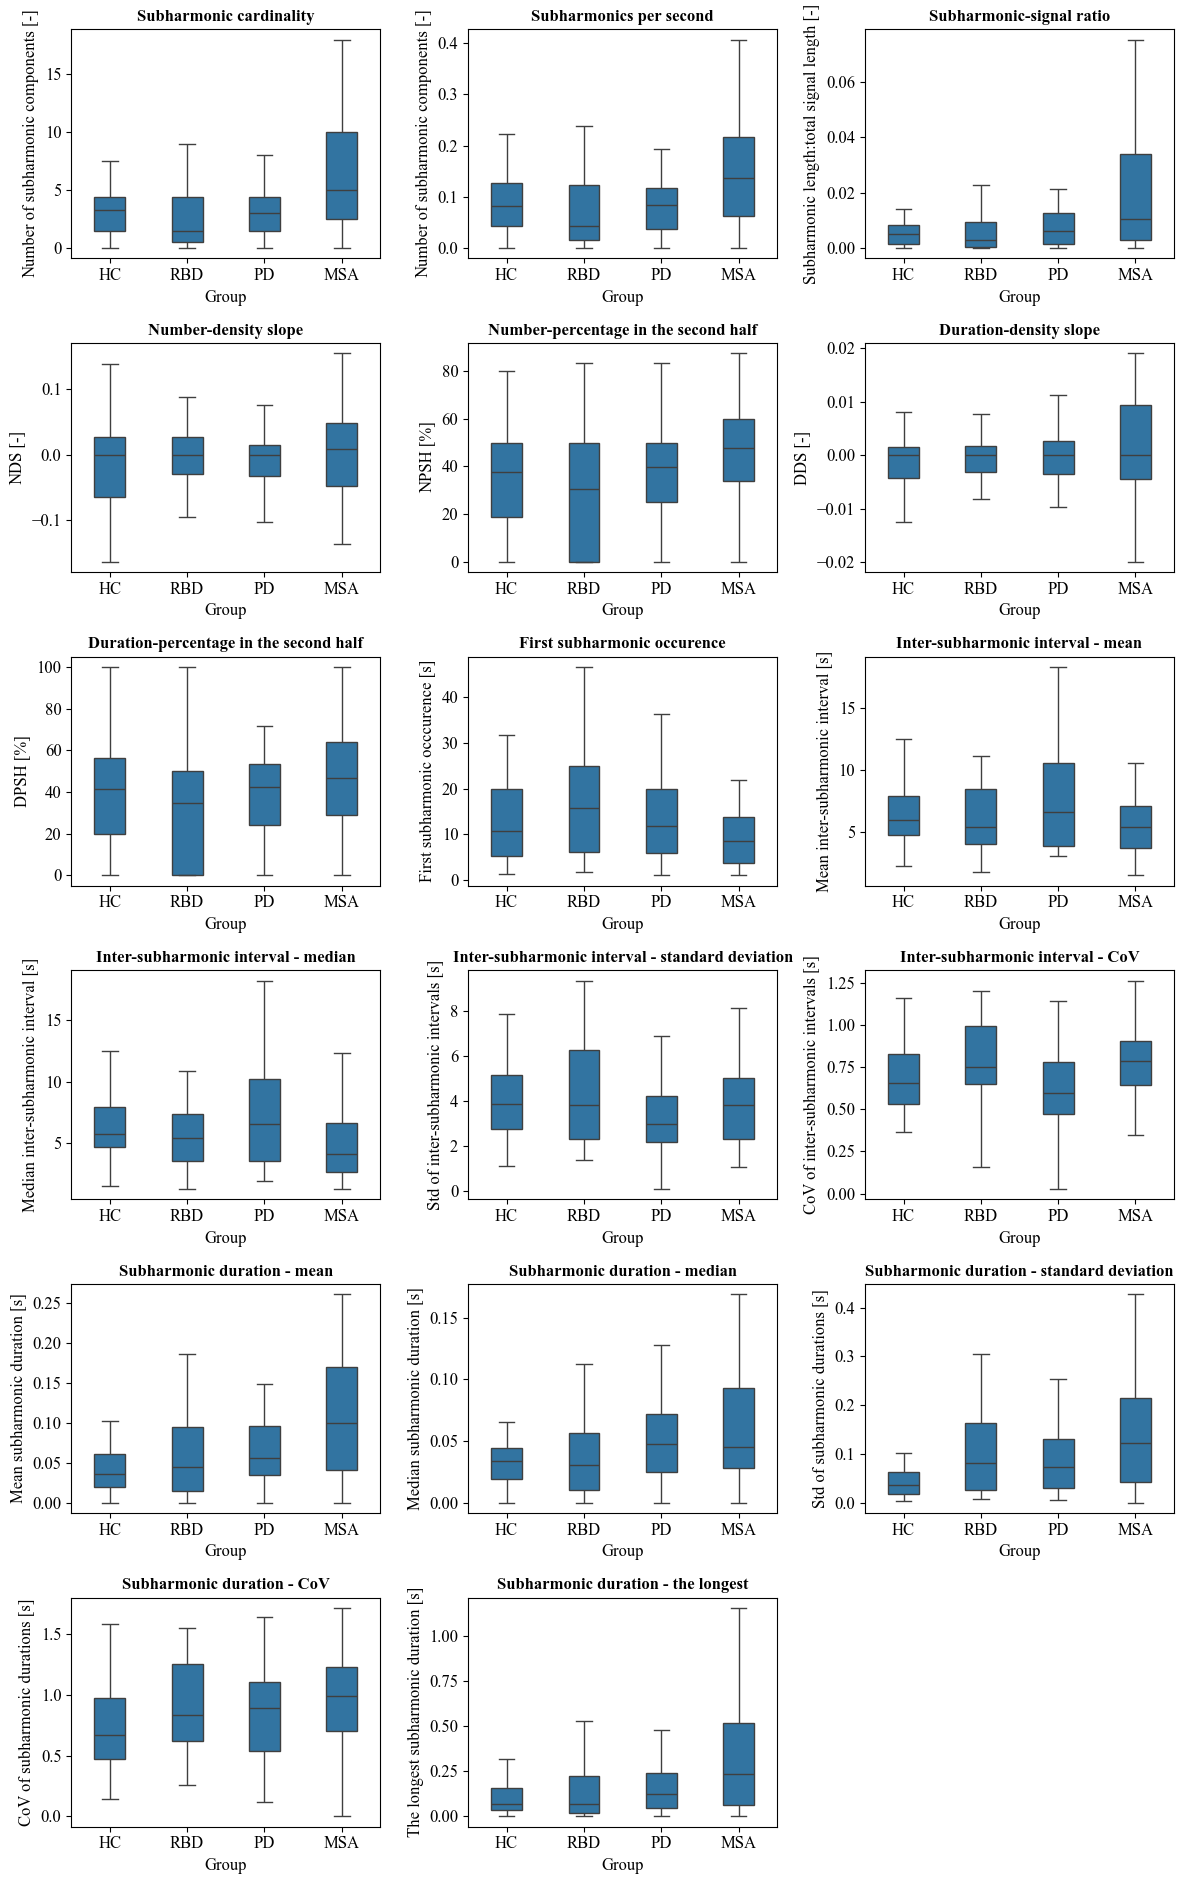

In [92]:

df_zahradnik = pd.read_csv("compressed_zahradnik_features.csv")

df_zahradnik["group"] = df_zahradnik["group"].replace("PN", "PD")


fig, axes = plt.subplots(6, 3, figsize=(12, 19))
# fig, axes = plt.subplots(5, 4, figsize=(14, 22))
# fig, axes = plt.subplots(3, 6, figsize=(24, 12))
axes = axes.flatten()

for i, (var, ydata, title) in enumerate(zip(variables.keys(), ylabels, variables.values())):

    plot_var = var

    if var == "pct_subharm_num_2nd_half":
        df_zahradnik["temp_plot"] = df_zahradnik[var] * 100
        plot_var = "temp_plot"
    elif var == "pct_subharm_dur_2nd_half":
        df_zahradnik["temp_plot"] = df_zahradnik[var] * 100
        plot_var = "temp_plot"

    sns.boxplot(
        data=df_zahradnik,
        x="group",
        y=plot_var,
        order=groups,
        showfliers=False,
        ax=axes[i],
        width=0.4,
        linewidth=1
    )

    axes[i].set_title(title, fontweight="bold")
    axes[i].set_ylabel(ydata)
    axes[i].set_xlabel("Group")

# remove unused subplot
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig("zahradnik_boxplots", dpi=300, bbox_inches="tight")
plt.show()


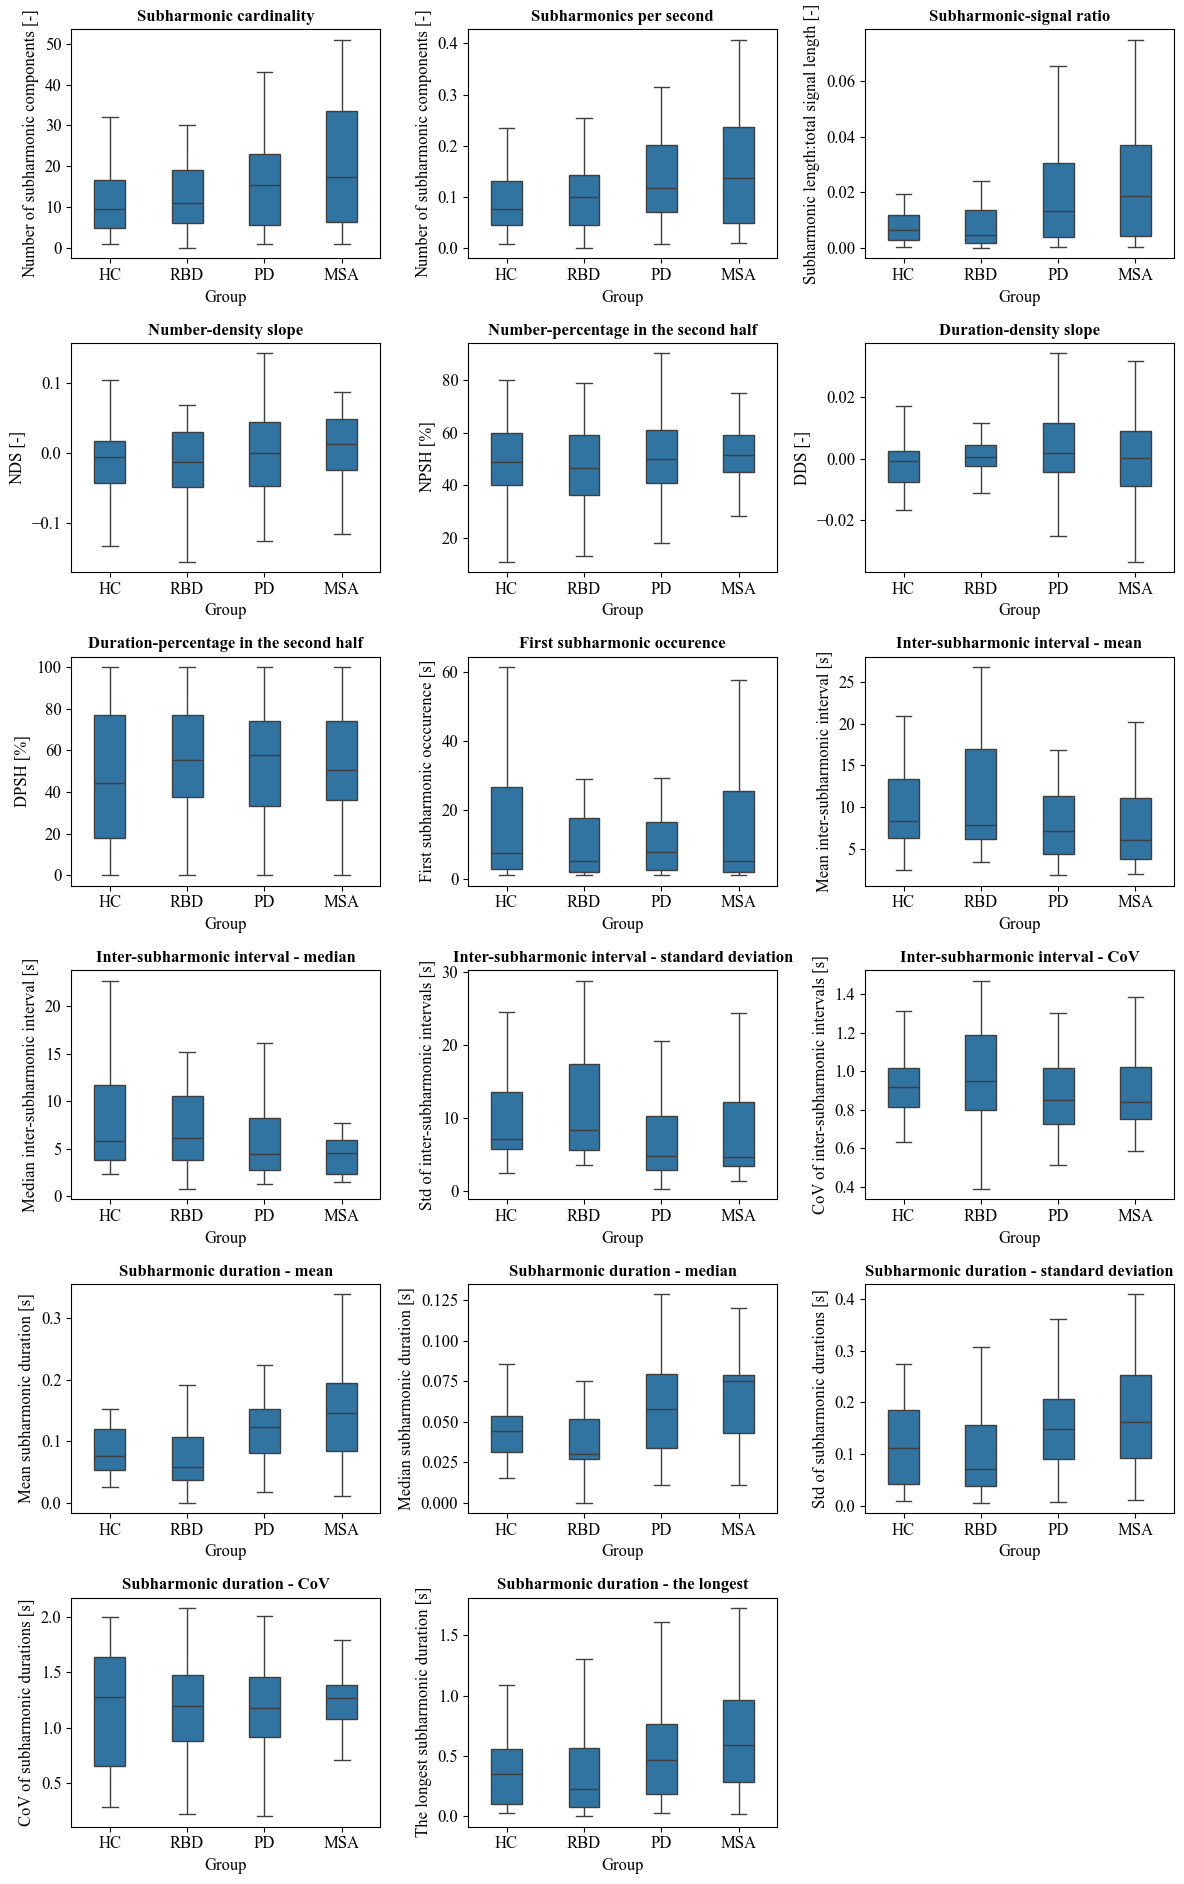

In [93]:

df_monolog = pd.read_csv("monolog_cont_speech_features.csv")
df_monolog["group"] = df_monolog["group"].replace("PN", "PD")

fig, axes = plt.subplots(6, 3, figsize=(12, 19))
# fig, axes = plt.subplots(5, 4, figsize=(14, 22))
# fig, axes = plt.subplots(3, 6, figsize=(24, 12))
axes = axes.flatten()

for i, (var, ydata, title) in enumerate(zip(variables.keys(), ylabels, variables.values())):

    plot_var = var

    if var == "pct_subharm_num_2nd_half":
        df_monolog["temp_plot"] = df_monolog[var] * 100
        plot_var = "temp_plot"
    elif var == "pct_subharm_dur_2nd_half":
        df_monolog["temp_plot"] = df_monolog[var] * 100
        plot_var = "temp_plot"

    sns.boxplot(
        data=df_monolog,
        x="group",
        y=plot_var,
        order=groups,
        showfliers=False,
        ax=axes[i],
        width=0.4,
        linewidth=1
    )

    axes[i].set_title(title, fontweight="bold", fontsize=fontsize)
    axes[i].set_ylabel(ydata, fontsize=fontsize)
    axes[i].set_xlabel("Group", fontsize=fontsize)

# remove unused subplot
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig("monolog_boxplots", dpi=300, bbox_inches="tight")
plt.show()


---------------------------------------------------------------
                     Subharmonic cardinality
---------------------------------------------------------------
        Source  ddof1         H     p-unc
Kruskal  group      3  16.05173  0.001107
N = 168
Effect eta squared: 0.0796
Effect epsilon squared: 0.0961

TIME FOR DUNN POST-HOC TEST
           HC       MSA        PD       RBD
HC   1.000000  0.045215  0.867897  0.525900
MSA  0.045215  1.000000  0.034722  0.000605
PD   0.867897  0.034722  1.000000  0.525900
RBD  0.525900  0.000605  0.525900  1.000000
           HC       RBD        PD       MSA
HC   1.000000  0.525900  0.867897  0.045215
RBD  0.525900  1.000000  0.525900  0.000605
PD   0.867897  0.525900  1.000000  0.034722
MSA  0.045215  0.000605  0.034722  1.000000

---------------------------------------------------------------
                     Subharmonics per second
---------------------------------------------------------------
        Source  ddof1          H  

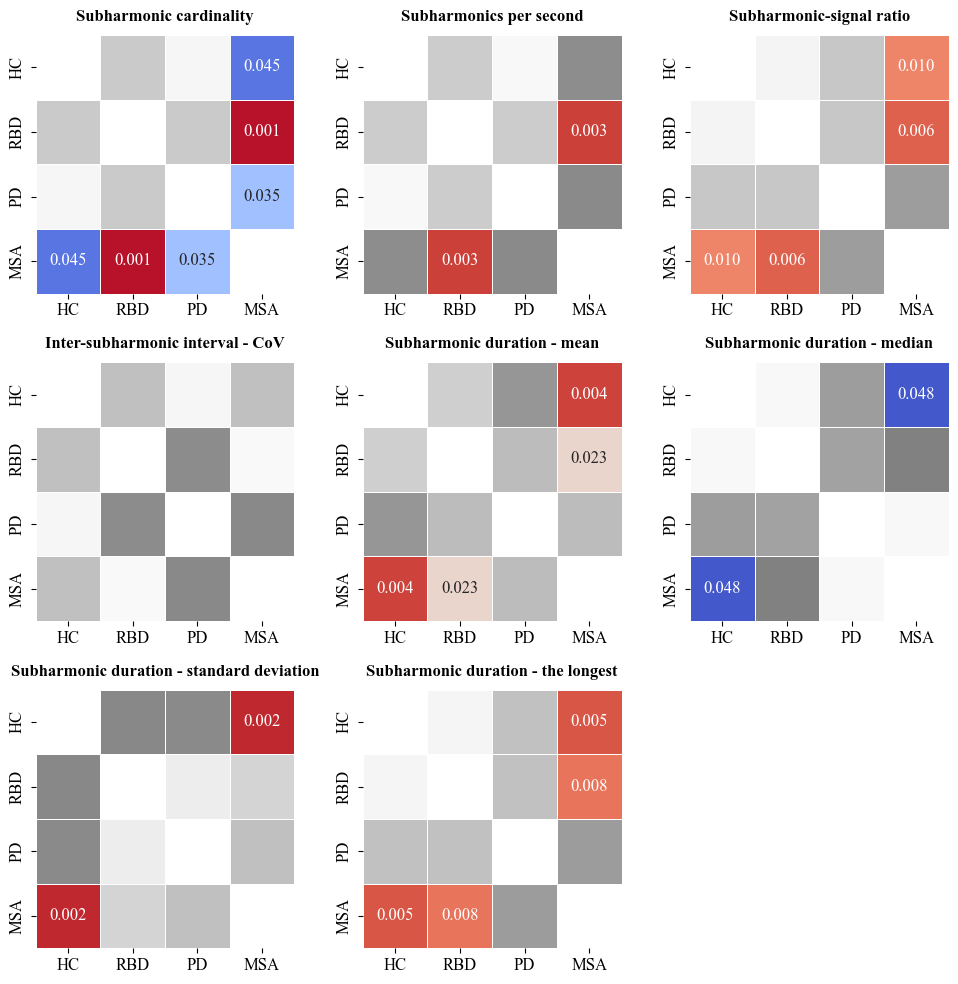

In [94]:
# ZAHRADNIK STATS

posthoc_counter = 0
posthoc_results = []

fig, axes = plt.subplots(3, 3, figsize=(10, 10))
axes = axes.flatten()

for i, (dv, label) in enumerate(variables.items()):
    print("---------------------------------------------------------------")
    print(f"                     {label}")
    print("---------------------------------------------------------------")

    df_clean = df_zahradnik.dropna(subset=[dv]).copy()

    # group_medians = df_clean[df_clean[dv] != 0].groupby("group")[dv].median()
    # group_medians = df_clean.groupby("group")[dv].median()
    # print("\nGroup medians:")
    # print(group_medians)

    # group_means = df_clean.groupby("group")[dv].mean()
    # print("\nGroup means:")
    # print(group_means)
    # print()

    # Shapiro-Wilk normality test
    # norm_results = pg.normality(data=df_clean, dv=dv, group="group") # -> norm_results.normal
    # if norm_results.normal.all():
    #     print("NORMAL <<<<<<<<<<<<<<<<<<<<<<<<<")
    # else:
    #     print("NON-NORMAL <<<<<<<<<<<<<<<<<<<<<<<<<")

    # Levene homoscedasticity test
    # homo_results = pg.homoscedasticity(data=df_clean, dv=dv, group="group") # -> homo_results.equal_var
    # if homo_results.equal_var.iloc[0]:
    #     print("HOMO <<<<<<<<<<<<<<<<<<<<<<<<<")
    # else:
    #     print("NON-HOMO <<<<<<<<<<<<<<<<<<<<<<<<<")

    # KRUSKAL-WALLIS GROUP COMPARISON
    kw = pg.kruskal(data=df_clean, dv=dv, between="group")
    print(kw)
    H = kw["H"].values[0]
    k = len(groups)
    n = len(df_clean)
    print(f"N = {n}")
    eta_sq = (H-k+1)/(n-k)
    eps_sq = H/(n-1)
    print(f"Effect eta squared: {eta_sq:.4f}")
    print(f"Effect epsilon squared: {eps_sq:.4f}")

    # print("\nMean ranks")
    # df_clean["rank"] = df_clean[dv].rank()
    # mean_ranks = df_clean.groupby("group")["rank"].mean()
    # print(mean_ranks)

    pval = kw["p-unc"].values[0]
    # POST-HOC TEST
    if pval <= 0.05:
        posthoc_counter += 1
        show_cbar = False #(posthoc_counter % 2 == 0) #or (dv == "longest_dur")
        print()
        print("TIME FOR DUNN POST-HOC TEST")
        dunn = sp.posthoc_dunn(df_clean, val_col=dv, group_col="group", p_adjust="holm")
        print(dunn)
        dunn = dunn.loc[groups, groups]
        print(dunn)
        reject = (dunn < 0.05)

        posthoc_results.append({"counter": posthoc_counter, "label": label, "dunn": dunn.copy()})

        n_ticks = 6
        ticks_grey = np.round(np.linspace(0.05, 1.0, n_ticks), 1)   # 1.0 → 0.05
        ticks_color = np.linspace(0.0, 0.05, n_ticks)

        ax = axes[posthoc_counter - 1]
        # plt.figure(figsize=(8, 5))
        sns.heatmap(dunn, mask=reject, fmt=".3f", cmap='Greys_r', cbar=show_cbar, linewidths=0.5, alpha = 0.5, cbar_kws={"label": "p-value", "ticks": ticks_grey}, square=True, vmin=0.05, vmax=1.0, ax=ax)
        sns.heatmap(dunn, mask=~reject, fmt=".3f", cmap='coolwarm_r', cbar=show_cbar, linewidths=0.5, annot=True, annot_kws={"size": 12}, square=True, vmin=0.0, vmax=0.05, cbar_kws={"ticks": ticks_color}, ax=ax)
        
        if show_cbar:
            cbar = ax.collections[0].colorbar
            cbar.set_label("p-value", labelpad=15, fontsize=fontsize)
        # plt.title(f"{label}", fontsize=15, pad=15, fontweight="bold")
        ax.set_title(label, fontsize=fontsize, pad=10, fontweight="bold")
        # plt.savefig(f"posthoc/monolog/{label}_posthoc.png", dpi=300)
        # plt.show()
    
    print()

for j in range(posthoc_counter, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig("posthoc_zahradnik_plot", dpi=300, bbox_inches="tight")
plt.show()

---------------------------------------------------------------
                     Subharmonic cardinality
---------------------------------------------------------------
        Source  ddof1         H     p-unc
Kruskal  group      3  7.749087  0.051492
Effect eta squared: 0.0291
Effect epsilon squared: 0.0467

---------------------------------------------------------------
                     Subharmonics per second
---------------------------------------------------------------
        Source  ddof1         H    p-unc
Kruskal  group      3  8.470865  0.03722
Effect eta squared: 0.0336
Effect epsilon squared: 0.0510

TIME FOR DUNN POST-HOC TEST
           HC       MSA        PD       RBD
HC   1.000000  0.101810  0.238157  1.000000
MSA  0.101810  1.000000  1.000000  0.156014
PD   0.238157  1.000000  1.000000  0.294190
RBD  1.000000  0.156014  0.294190  1.000000
           HC       RBD        PD       MSA
HC   1.000000  1.000000  0.238157  0.101810
RBD  1.000000  1.000000  0.294190 

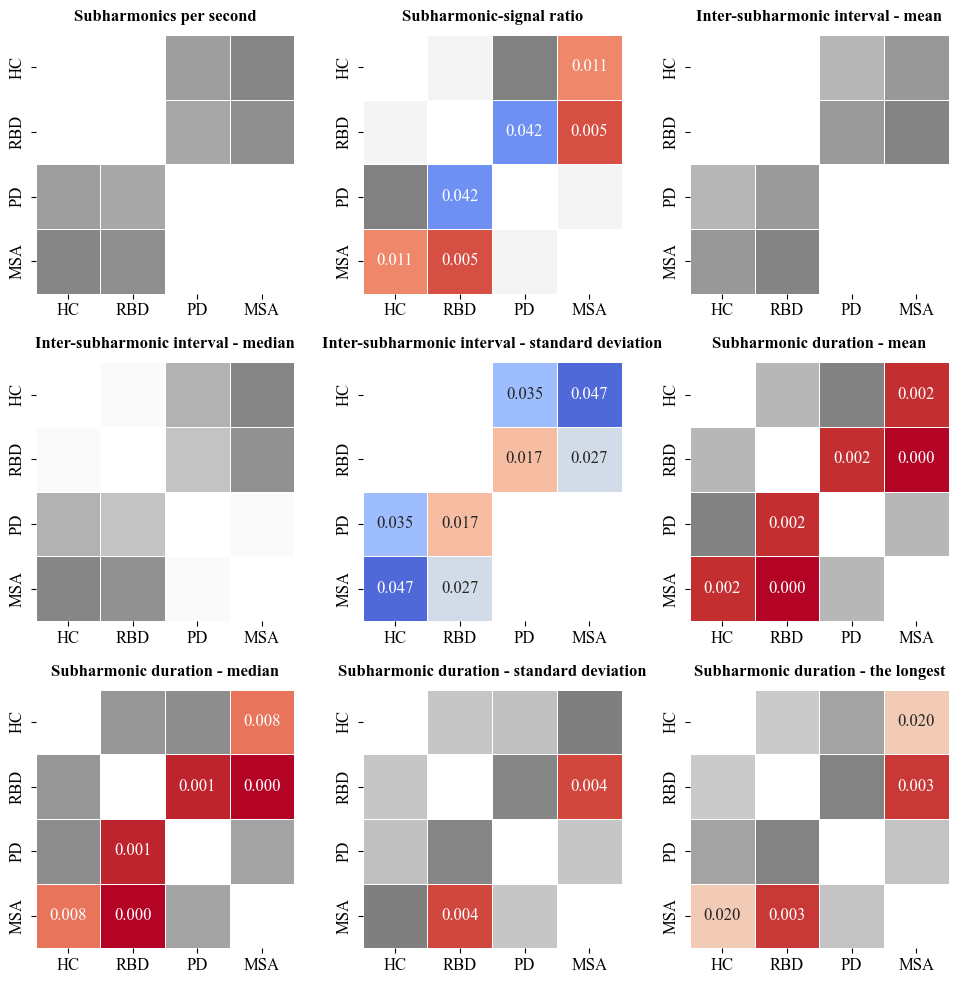

In [95]:
# MONOLOG STATS

posthoc_counter = 0
posthoc_results = []

fig, axes = plt.subplots(3, 3, figsize=(10, 10))
axes = axes.flatten()

for i, (dv, label) in enumerate(variables.items()):
    print("---------------------------------------------------------------")
    print(f"                     {label}")
    print("---------------------------------------------------------------")

    df_clean = df_monolog.dropna(subset=[dv]).copy()

    # group_medians = df_clean[df_clean[dv] != 0].groupby("group")[dv].median()
    # group_medians = df_clean.groupby("group")[dv].median()
    # print("\nGroup medians:")
    # print(group_medians)

    # group_means = df_clean.groupby("group")[dv].mean()
    # print("\nGroup means:")
    # print(group_means)
    # print()

    # Shapiro-Wilk normality test
    # norm_results = pg.normality(data=df_clean, dv=dv, group="group") # -> norm_results.normal
    # if norm_results.normal.all():
    #     print("NORMAL <<<<<<<<<<<<<<<<<<<<<<<<<")
    # else:
    #     print("NON-NORMAL <<<<<<<<<<<<<<<<<<<<<<<<<")

    # Levene homoscedasticity test
    # homo_results = pg.homoscedasticity(data=df_clean, dv=dv, group="group") # -> homo_results.equal_var
    # if homo_results.equal_var.iloc[0]:
    #     print("HOMO <<<<<<<<<<<<<<<<<<<<<<<<<")
    # else:
    #     print("NON-HOMO <<<<<<<<<<<<<<<<<<<<<<<<<")

    # KRUSKAL-WALLIS GROUP COMPARISON
    kw = pg.kruskal(data=df_clean, dv=dv, between="group")
    print(kw)
    H = kw["H"].values[0]
    k = len(groups)
    n = len(df_clean)
    eta_sq = (H-k+1)/(n-k)
    eps_sq = H/(n-1)
    print(f"Effect eta squared: {eta_sq:.4f}")
    print(f"Effect epsilon squared: {eps_sq:.4f}")

    # print("\nMean ranks")
    # df_clean["rank"] = df_clean[dv].rank()
    # mean_ranks = df_clean.groupby("group")["rank"].mean()
    # print(mean_ranks)

    pval = kw["p-unc"].values[0]
    # POST-HOC TEST
    if pval <= 0.05:
        posthoc_counter += 1
        show_cbar = False #(posthoc_counter % 2 == 0) #or (dv == "longest_dur")
        print()
        print("TIME FOR DUNN POST-HOC TEST")
        dunn = sp.posthoc_dunn(df_clean, val_col=dv, group_col="group", p_adjust="holm")
        print(dunn)
        dunn = dunn.loc[groups, groups]
        print(dunn)
        reject = (dunn < 0.05)

        posthoc_results.append({"counter": posthoc_counter, "label": label, "dunn": dunn.copy()})

        n_ticks = 6
        ticks_grey = np.round(np.linspace(0.05, 1.0, n_ticks), 1)   # 1.0 → 0.05
        ticks_color = np.linspace(0.0, 0.05, n_ticks)

        ax = axes[posthoc_counter - 1]
        # plt.figure(figsize=(8, 5))
        sns.heatmap(dunn, mask=reject, fmt=".3f", cmap='Greys_r', cbar=show_cbar, linewidths=0.5, alpha = 0.5, cbar_kws={"label": "p-value", "ticks": ticks_grey}, square=True, vmin=0.05, vmax=1.0, ax=ax)
        sns.heatmap(dunn, mask=~reject, fmt=".3f", cmap='coolwarm_r', cbar=show_cbar, linewidths=0.5, annot=True, annot_kws={"size": 12}, square=True, vmin=0.0, vmax=0.05, cbar_kws={"ticks": ticks_color}, ax=ax)
        
        if show_cbar:
            cbar = ax.collections[0].colorbar
            cbar.set_label("p-value", labelpad=15)
        # plt.title(f"{label}", fontsize=15, pad=15, fontweight="bold")
        ax.set_title(label, fontsize=fontsize, pad=10, fontweight="bold")
        # plt.savefig(f"posthoc/monolog/{label}_posthoc.png", dpi=300)
        # plt.show()
    
    print()

for j in range(posthoc_counter, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig("posthoc_monolog_plot", dpi=300, bbox_inches="tight")
plt.show()